# Ejercicio 13: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

## Paso 1: Obtener embeddings de imágenes y textos con CLIP

In [9]:
import requests
from PIL import Image
from io import BytesIO
from sentence_transformers import SentenceTransformer

# Cargar modelo CLIP
model = SentenceTransformer('clip-ViT-B-32')

image_urls = {
    "dog": "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
    "cat": "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
    "shark": "https://upload.wikimedia.org/wikipedia/commons/5/56/White_shark.jpg",
    "building": "https://upload.wikimedia.org/wikipedia/commons/1/10/Empire_State_Building_%28aerial_view%29.jpg"
}

texts = [
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a shark",     
    "a photo of a building",   
]
text_labels = ["texto:dog", "texto:cat", "texto:shark", "texto:building"]

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8'
}

# Descargar imágenes
images = []
image_labels = []
for label, url in image_urls.items():
    try:
        # Añadimos el headers
        resp = requests.get(url, headers=headers, timeout=10)
        resp.raise_for_status() 
        
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.thumbnail((400, 400)) 
        
        images.append(img)
        image_labels.append(f"img:{label}")
        print(f"✓ Imagen '{label}' descargada con éxito: {img.size}")
    except Exception as e:
        print(f"✗ Error descargando '{label}': {e}")

# Calcular embeddings
if images:
    img_embeddings  = model.encode(images,  convert_to_numpy=True, normalize_embeddings=True)
    text_embeddings = model.encode(texts,   convert_to_numpy=True, normalize_embeddings=True)

    print(f"\nEmbeddings de imágenes: {img_embeddings.shape}")
    print(f"Embeddings de textos:   {text_embeddings.shape}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 6809.80it/s]


✓ Imagen 'dog' descargada con éxito: (400, 330)
✓ Imagen 'cat' descargada con éxito: (300, 400)
✓ Imagen 'shark' descargada con éxito: (400, 278)
✓ Imagen 'building' descargada con éxito: (266, 400)

Embeddings de imágenes: (4, 512)
Embeddings de textos:   (4, 512)


## Paso 2: Verificar que ambos viven en el mismo espacio vectorial

In [10]:
from numpy.linalg import norm
import numpy as np

# IMPRESIÓN DE TABLA 1: DIMENSIONES
print("\n=== Dimensiones ===")
print("-" * 45)
print(f"| {'Tipo de Embedding':<22} | {'Dimensión':<14} |")
print("-" * 45)
print(f"| {'Imágenes':<22} | {img_embeddings.shape[1]:<14} |")
print(f"| {'Textos':<22} | {text_embeddings.shape[1]:<14} |")
print("-" * 45)

# IMPRESIÓN DE TABLA 2: NORMAS
print("\n=== Normas de los Vectores (Normalizados) ===")
print("-" * 45)
print(f"| {'Etiqueta':<22} | {'Norma':<14} |")
print("-" * 45)
for i, lbl in enumerate(image_labels):
    print(f"| {lbl:<22} | {norm(img_embeddings[i]):<14.4f} |")
for i, lbl in enumerate(text_labels):
    print(f"| {lbl:<22} | {norm(text_embeddings[i]):<14.4f} |")
print("-" * 45)

# IMPRESIÓN DE TABLA 3: SIMILITUD DIAGONAL
print("\n=== Cosine Similarity (Imagen vs su propio Texto) ===")
# Como los embeddings ya vienen normalizados por la librería, podemos calcular la Similitud del Coseno directamente con un producto punto.
print("-" * 65)
print(f"| {'Imagen':<20} | {'Texto':<20} | {'Similitud':<14} |")
print("-" * 65)
for i in range(len(images)):
    # Usamos directamente img_embeddings y text_embeddings
    sim = float(np.dot(img_embeddings[i], text_embeddings[i]))
    print(f"| {image_labels[i]:<20} | {text_labels[i]:<20} | {sim:<14.4f} |")
print("-" * 65)


=== Dimensiones ===
---------------------------------------------
| Tipo de Embedding      | Dimensión      |
---------------------------------------------
| Imágenes               | 512            |
| Textos                 | 512            |
---------------------------------------------

=== Normas de los Vectores (Normalizados) ===
---------------------------------------------
| Etiqueta               | Norma          |
---------------------------------------------
| img:dog                | 1.0000         |
| img:cat                | 1.0000         |
| img:shark              | 1.0000         |
| img:building           | 1.0000         |
| texto:dog              | 1.0000         |
| texto:cat              | 1.0000         |
| texto:shark            | 1.0000         |
| texto:building         | 1.0000         |
---------------------------------------------

=== Cosine Similarity (Imagen vs su propio Texto) ===
-----------------------------------------------------------------
| Image

## Paso 3: Proyectar vectores a 2D con PCA y graficarlos


=== Preparando visualización ===
Varianza explicada por PC1+PC2: 72.8%


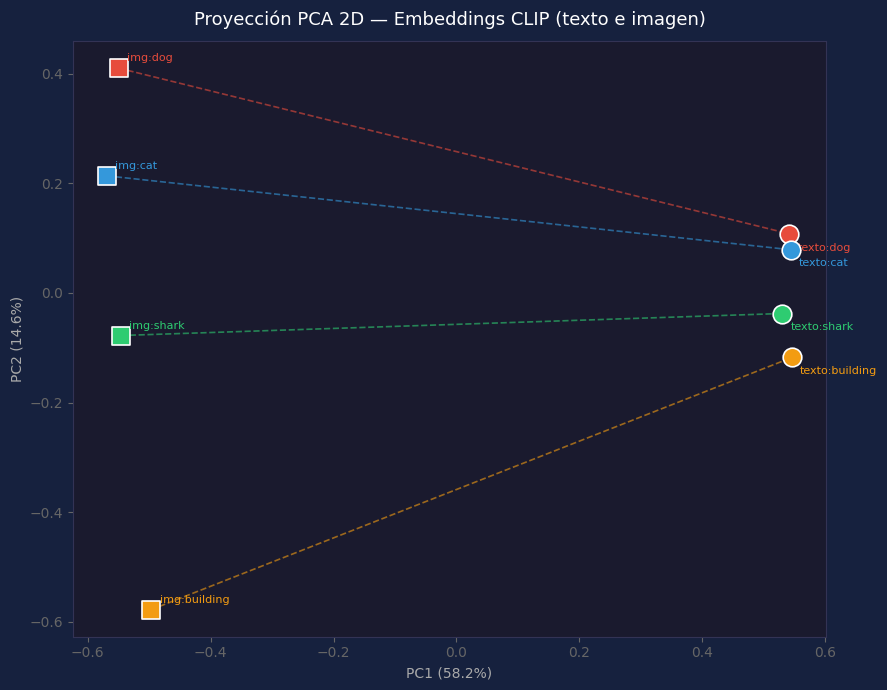

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
import numpy as np
from matplotlib.lines import Line2D

print("\n=== Preparando visualización ===")

# Juntar todos los vectores usando las variables normalizadas directamente
all_embeddings = np.vstack([img_embeddings, text_embeddings])
all_labels     = image_labels + text_labels

# Proyección PCA a 2D
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(all_embeddings)

print(f"Varianza explicada por PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Colores por concepto (ahora son 4 pares)
concept_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
n = len(images)

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#16213e")


for i in range(n):
    c = concept_colors[i]
    
    # Imagen: marcador cuadrado
    ax.scatter(coords_2d[i, 0], coords_2d[i, 1],
               marker="s", s=180, color=c, edgecolors="white", linewidths=1.2, zorder=3)
    ax.annotate(image_labels[i], (coords_2d[i, 0], coords_2d[i, 1]),
                textcoords="offset points", xytext=(6, 5),
                fontsize=8, color=c)
    
    # Texto: marcador círculo
    ax.scatter(coords_2d[n+i, 0], coords_2d[n+i, 1],
               marker="o", s=180, color=c, edgecolors="white", linewidths=1.2, zorder=3)
    ax.annotate(text_labels[i], (coords_2d[n+i, 0], coords_2d[n+i, 1]),
                textcoords="offset points", xytext=(6, -12),
                fontsize=8, color=c)
    
    # Línea que une el par (imagen <--> texto)
    ax.plot([coords_2d[i,0], coords_2d[n+i,0]],
            [coords_2d[i,1], coords_2d[n+i,1]],
            color=c, linewidth=1.2, linestyle="--", alpha=0.6)


ax.set_title("Proyección PCA 2D — Embeddings CLIP (texto e imagen)",
             color="white", fontsize=13, pad=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", color="#aaaaaa")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", color="#aaaaaa")
ax.tick_params(colors="#666666")

for spine in ax.spines.values():
    spine.set_edgecolor("#333355")

plt.tight_layout()

plt.show()

## Paso 4: Verificar emparejamientos con Cosine Similarity


=== BÚSQUEDA TEXTO → IMAGEN ===
--------------------------------------------------------------------------------
| Texto de Entrada   | Mejor Imagen Encontrada   | Similitud  | Resultado       |
--------------------------------------------------------------------------------
| texto:dog          | img:dog                   | 0.2680     | ✓ Correcto      |
| texto:cat          | img:cat                   | 0.2870     | ✓ Correcto      |
| texto:shark        | img:shark                 | 0.2860     | ✓ Correcto      |
| texto:building     | img:building              | 0.2463     | ✓ Correcto      |
--------------------------------------------------------------------------------

=== BÚSQUEDA IMAGEN → TEXTO ===
--------------------------------------------------------------------------------
| Imagen de Entrada  | Mejor Texto Encontrado    | Similitud  | Resultado       |
--------------------------------------------------------------------------------
| img:dog            | texto:dog     

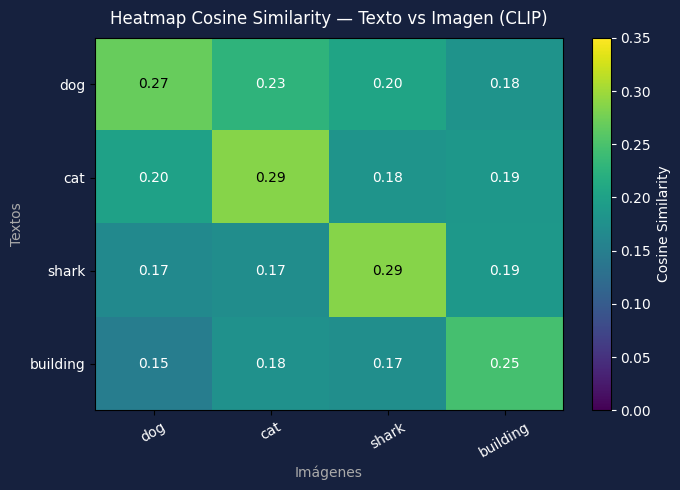

In [12]:
# Matriz de similitud texto→imagen (n_texts × n_images)
# Usamos directamente las variables normalizadas
sim_matrix = np.dot(text_embeddings, img_embeddings.T)  # shape: (4, 4)

# IMPRESIÓN DE TABLA 1: TEXTO -> IMAGEN
print("\n=== BÚSQUEDA TEXTO → IMAGEN ===")
print("-" * 80)
# Ajustamos los espacios de cada columna (<18 significa alineado a la izquierda con 18 espacios)
print(f"| {'Texto de Entrada':<18} | {'Mejor Imagen Encontrada':<25} | {'Similitud':<10} | {'Resultado':<15} |")
print("-" * 80)
for i, tlbl in enumerate(text_labels):
    best_j = np.argmax(sim_matrix[i])
    sim_val = f"{sim_matrix[i,best_j]:.4f}"
    resultado = "✓ Correcto" if i == best_j else "✗ Incorrecto"
    print(f"| {tlbl:<18} | {image_labels[best_j]:<25} | {sim_val:<10} | {resultado:<15} |")
print("-" * 80)

# IMPRESIÓN DE TABLA 2: IMAGEN -> TEXTO
print("\n=== BÚSQUEDA IMAGEN → TEXTO ===")
print("-" * 80)
print(f"| {'Imagen de Entrada':<18} | {'Mejor Texto Encontrado':<25} | {'Similitud':<10} | {'Resultado':<15} |")
print("-" * 80)
for j, ilbl in enumerate(image_labels):
    best_i = np.argmax(sim_matrix[:, j])
    sim_val = f"{sim_matrix[best_i,j]:.4f}"
    resultado = "✓ Correcto" if best_i == j else "✗ Incorrecto"
    print(f"| {ilbl:<18} | {text_labels[best_i]:<25} | {sim_val:<10} | {resultado:<15} |")
print("-" * 80)

# VISUALIZACIÓN DEL HEATMAP
print("\n=== Mostrando Heatmap (Matriz de Similitud) ===")
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("#1a1a2e")
fig.patch.set_facecolor("#16213e")

im = ax.imshow(sim_matrix, cmap="viridis", aspect="auto", vmin=0, vmax=0.35)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.set_label("Cosine Similarity", color="white")

ax.set_xticks(range(len(image_labels)))
ax.set_yticks(range(len(text_labels)))
ax.set_xticklabels([l.replace("img:","") for l in image_labels], color="white", rotation=30)
ax.set_yticklabels([l.replace("texto:","") for l in text_labels], color="white")

# Añadir valores numéricos en cada celda
for i in range(len(text_labels)):
    for j in range(len(image_labels)):
        # Cambiamos el color del texto a negro si la similitud es alta (colores claros en viridis)
        text_color = "black" if sim_matrix[i,j] > 0.25 else "white"
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
                ha="center", va="center", fontsize=10,
                color=text_color)

ax.set_title("Heatmap Cosine Similarity — Texto vs Imagen (CLIP)",
             color="white", fontsize=12, pad=10)
ax.set_xlabel("Imágenes", color="#aaaaaa")
ax.set_ylabel("Textos", color="#aaaaaa")

plt.tight_layout()
plt.show()